In [1]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
from sklearn.model_selection import train_test_split
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [102]:
# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-592000.npy",
    "labels": "labels_checkpoint-592000.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))  # Load numpy file from bytes

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

# Define words and their labels
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]

word_labels = dict(words_labels)
print("Word labels:", word_labels)

# Create word_to_indices mapping
word_to_indices = {}
current_idx = 0

for word, label in words_labels:
    # Count embeddings for this word
    count = 0
    start_idx = current_idx
    
    while current_idx < len(y) and y[current_idx] == label:
        count += 1
        current_idx += 1
    
    # Store indices for this word
    if count > 0:
        word_to_indices[word] = list(range(start_idx, start_idx + count))
    else:
        word_to_indices[word] = []

# Create averaged embeddings (one per word)
words = []
averaged_embeddings = []
word_label_list = []

for word, indices in word_to_indices.items():
    if len(indices) == 0:
        print(f"Skipping '{word}' due to zero embeddings.")
        continue
    
    # Average the embeddings for this word
    word_embeddings = X[indices]
    avg_embedding = np.median(word_embeddings, axis=0)
    
    words.append(word)
    averaged_embeddings.append(avg_embedding)
    word_label_list.append(word_labels[word])

# Convert to numpy arrays
X_avg = np.array(averaged_embeddings)
y_avg = np.array(word_label_list)

print(f"Number of words with embeddings: {len(words)}")
print(f"Averaged embeddings shape: {X_avg.shape}")
print(f"Averaged labels shape: {y_avg.shape}")

# Split at word level
X_train, X_test, y_train, y_test, words_train, words_test = train_test_split(
    X_avg, y_avg, words, test_size=0.3, random_state=42, stratify=y_avg
)

# Print results
print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")
print(f"Training label distribution: {np.bincount(y_train)}")
print(f"Testing label distribution: {np.bincount(y_test)}")
print(f"Words in training set: {words_train}")
print(f"Words in test set: {words_test}")

Feature matrix shape: (117652, 768)
Labels shape: (117652,)
Word labels: {'man': 1, 'vrouw': 0, 'broer': 1, 'zus': 0, 'zoon': 1, 'dochter': 0, 'neef': 1, 'nicht': 0, 'vader': 1, 'moeder': 0, 'opa': 1, 'oma': 0, 'kleinzoon': 1, 'kleindochter': 0, 'grootvader': 1, 'grootmoeder': 0, 'oom': 1, 'tante': 0, 'papa': 1, 'mama': 0, 'jongen': 1, 'meisje': 0, 'jongetje': 1, 'meid': 0, 'schoonvader': 1, 'schoonmoeder': 0, 'schoonzoon': 1, 'schoondochter': 0, 'stiefvader': 1, 'stiefmoeder': 0, 'stiefzoon': 1, 'stiefdochter': 0, 'peetvader': 1, 'peetmoeder': 0, 'bruidegom': 1, 'bruid': 0, 'meneer': 1, 'mevrouw': 0, 'mijnheer': 1, 'heer': 1, 'dame': 0, 'kerel': 1, 'mister': 1, 'miss': 0, 'mr': 1, 'ms': 0, 'prins': 1, 'prinses': 0, 'koning': 1, 'koningin': 0, 'lord': 1, 'lady': 0, 'baron': 1, 'barones': 0, 'hertog': 1, 'hertogin': 0, 'monnik': 1, 'non': 0, 'hijzelf': 1, 'zijzelf': 0, 'mannelijk': 1, 'vrouwelijk': 0, 'gentleman': 1, 'gozer': 1, 'wijf': 0}
Skipping 'heer' due to zero embeddings.
Skippin

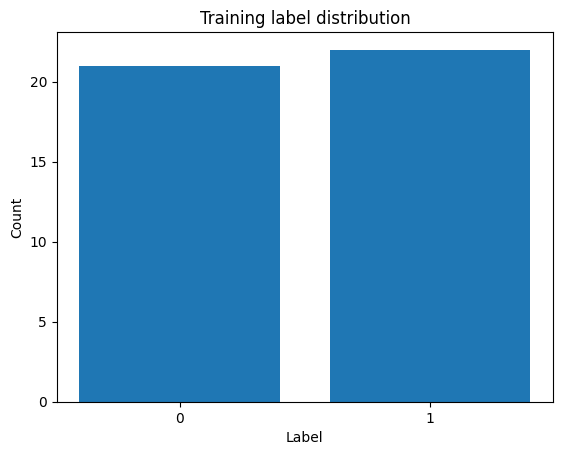

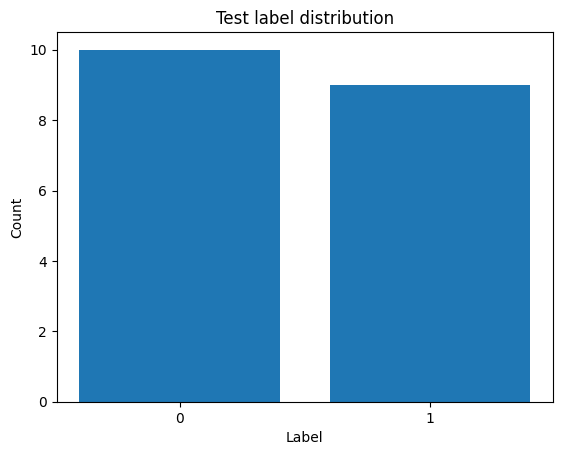

Percentage of majority class in training set: 51.16%


In [103]:
import matplotlib.pyplot as plt

# Plot the distribution of labels in the training set
plt.hist(y_train, bins=2, rwidth=0.8)
plt.xticks([0.25, 0.75], ['0', '1'])
plt.title("Training label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Plot the distribution of labels in the test set
plt.hist(y_test, bins=2, rwidth=0.8)
plt.xticks([0.25, 0.75], ['0', '1'])
plt.title("Test label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Get the percentage of the majority class in the training set
majority_class_percentage = max(np.bincount(y_train)) / len(y_train) * 100
print(f"Percentage of majority class in training set: {majority_class_percentage:.2f}%")

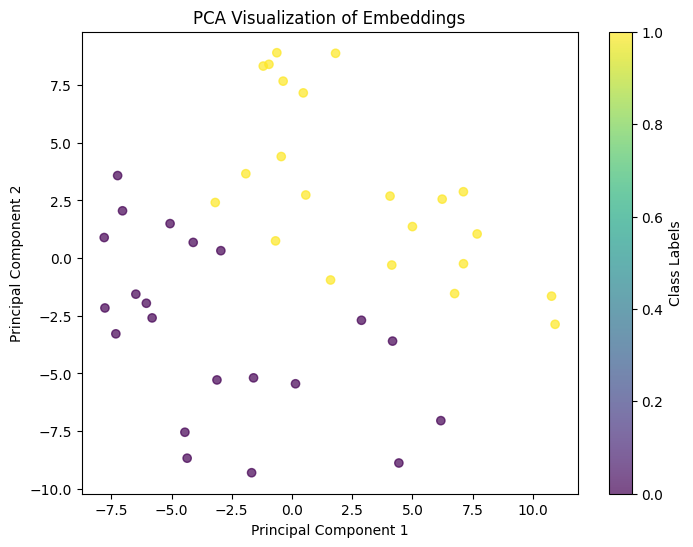

In [104]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Scatter plot of PCA-reduced features
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Class Labels")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Embeddings")
plt.show()

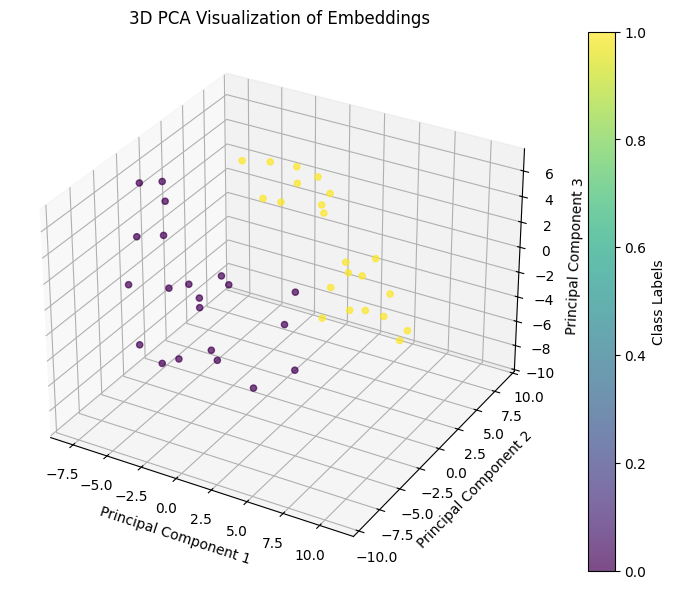

In [105]:
# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train)

# 3D Scatter plot of PCA-reduced features
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)

# Labels and color bar
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA Visualization of Embeddings")
plt.colorbar(scatter, label="Class Labels")

# Show plot
plt.show()

In [106]:
# Initialize SVM classifier
svm_model = SVC(kernel="rbf", C=1, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on test set
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8421052631578947
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.88      0.78      0.82         9

    accuracy                           0.84        19
   macro avg       0.85      0.84      0.84        19
weighted avg       0.85      0.84      0.84        19



In [107]:
# Initialize SVM classifier
svm_model = SVC(kernel="sigmoid", C=10, gamma='scale', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict on test set
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8421052631578947
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.88      0.78      0.82         9

    accuracy                           0.84        19
   macro avg       0.85      0.84      0.84        19
weighted avg       0.85      0.84      0.84        19



In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100], 
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'] 
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search on training data
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Print best parameters
print("Best Parameters from Grid Search:", grid_search.best_params_)
print("Best Model from Grid Search:", best_model)

Best Parameters from Grid Search: {'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best Model from Grid Search: SVC(C=1, kernel='sigmoid')


In [109]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the test set
y_test_pred = best_model.predict(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.8947368421052632
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.89      0.89      0.89         9

    accuracy                           0.89        19
   macro avg       0.89      0.89      0.89        19
weighted avg       0.89      0.89      0.89        19



In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train logistic regression model
logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)

# Predict on test set
y_pred = logreg_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.20f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.84210526315789469010
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.88      0.78      0.82         9

    accuracy                           0.84        19
   macro avg       0.85      0.84      0.84        19
weighted avg       0.85      0.84      0.84        19

